In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
!pip uninstall -y transformers
!pip install -q transformers==4.52.4 sentencepiece

Found existing installation: transformers 5.0.0
Uninstalling transformers-5.0.0:
  Successfully uninstalled transformers-5.0.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 64.3 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 80.1 MB/s eta 0:00:00:00:01


In [ ]:
import os
os.kill(os.getpid(), 9)

In [1]:
import transformers
print(transformers.__version__)

4.52.4


In [15]:
import os
import random
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split

import torch

from transformers import (
    ViTImageProcessor,
    ViTModel,
    GPT2Tokenizer,
    GPT2LMHeadModel,
    VisionEncoderDecoderModel
)

In [16]:
# Flickr30k
FLICKR_IMAGE_DIR = "/kaggle/input/datasets/eeshawn/flickr30k/flickr30k_images"
FLICKR_CAPTIONS_PATH = "/kaggle/input/datasets/eeshawn/flickr30k/captions.txt"

# COCO
COCO_BASE = "/kaggle/input/datasets/alifshahariar/ms-coco-2017-captions-csv-format/coco-captions"
COCO_TRAIN_IMAGE_DIR = f"{COCO_BASE}/train"
COCO_VAL_IMAGE_DIR   = f"{COCO_BASE}/val"
COCO_TRAIN_CAPTIONS  = f"{COCO_BASE}/coco-train-2017-captions.csv"
COCO_VAL_CAPTIONS    = f"{COCO_BASE}/coco-val-2017-captions.csv"

MODEL_SAVE_PATH = "/kaggle/working/best_model"

os.makedirs(MODEL_SAVE_PATH, exist_ok=True)


In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


In [23]:
def clean_caption(text):
    text = str(text)
    text = text.strip()
    text = " ".join(text.split())
    return text

# ---------- Flickr30k ----------
captions_df = pd.read_csv(FLICKR_CAPTIONS_PATH)
captions_df["comment"] = captions_df["comment"].apply(clean_caption)

mapping_flickr = {}
for _, row in captions_df.iterrows():
    full_path = os.path.join(FLICKR_IMAGE_DIR, row["image_name"])
    mapping_flickr.setdefault(full_path, []).append(row["comment"])

print("Flickr30k images:", len(mapping_flickr))

# ---------- COCO ----------
def detect_columns(df):
    img_candidates = ["image", "image_id", "file_name", "filename", "image_name"]
    cap_candidates = ["caption", "captions", "comment", "text"]
    img_col = next((c for c in img_candidates if c in df.columns), None)
    cap_col = next((c for c in cap_candidates if c in df.columns), None)
    return img_col, cap_col

def load_coco_csv(csv_path, image_dir):
    df = pd.read_csv(csv_path)
    img_col, cap_col = detect_columns(df)

    if img_col is None or cap_col is None:
        print("مش عارف أحدد الأعمدة تلقائي. الأعمدة الموجودة:", df.columns.tolist())
        raise ValueError("حدد image_col و caption_col يدوي")

    df[cap_col] = df[cap_col].apply(clean_caption)

    mapping = {}
    missing = 0
    for _, row in df.iterrows():
        image_name = str(row[img_col])
        if not image_name.lower().endswith((".jpg", ".jpeg", ".png")):
            image_name = image_name.zfill(12) + ".jpg"

        full_path = os.path.join(image_dir, image_name)
        if not os.path.exists(full_path):
            missing += 1
            continue

        mapping.setdefault(full_path, []).append(row[cap_col])

    print(f"{os.path.basename(csv_path)} -> {len(mapping)} loaded, {missing} missing (columns used: {img_col}, {cap_col})")
    return mapping

mapping_coco_train = load_coco_csv(COCO_TRAIN_CAPTIONS, COCO_TRAIN_IMAGE_DIR)
mapping_coco_val   = load_coco_csv(COCO_VAL_CAPTIONS, COCO_VAL_IMAGE_DIR)
mapping_coco = {**mapping_coco_train, **mapping_coco_val}

print("COCO total:", len(mapping_coco))

# ---------- دمج نهائي (Flickr30k + COCO كاملة) ----------
mapping = {**mapping_flickr, **mapping_coco}
print("Grand total images:", len(mapping))

# ---------- Split ----------
images = list(mapping.keys())

train_images, temp_images = train_test_split(images, test_size=0.30, random_state=42)
val_images, test_images = train_test_split(temp_images, test_size=0.50, random_state=42)

train_mapping = {img: mapping[img] for img in train_images}
val_mapping = {img: mapping[img] for img in val_images}
test_mapping = {img: mapping[img] for img in test_images}

print("Train :", len(train_mapping))
print("Validation :", len(val_mapping))
print("Test :", len(test_mapping))


Flickr30k images: 31783
coco-train-2017-captions.csv -> 118287 loaded, 0 missing (columns used: image, caption)
coco-val-2017-captions.csv -> 5000 loaded, 0 missing (columns used: image, caption)
COCO total: 123287
Grand total images: 155070
Train : 108549
Validation : 23260
Test : 23261


In [4]:
from transformers import ViTImageProcessor

processor = ViTImageProcessor.from_pretrained(
    "google/vit-base-patch16-224-in21k"
)

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

In [5]:
from transformers import ViTModel

encoder = ViTModel.from_pretrained(
    "google/vit-base-patch16-224-in21k"
)

config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

In [6]:
from transformers import GPT2Tokenizer

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

In [7]:
from transformers import GPT2LMHeadModel

decoder = GPT2LMHeadModel.from_pretrained("gpt2")

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

In [8]:
from transformers import VisionEncoderDecoderModel

model = VisionEncoderDecoderModel.from_encoder_decoder_pretrained(
    "google/vit-base-patch16-224-in21k",
    "gpt2"
)

Some weights of GPT2LMHeadModel were not initialized from the model checkpoint at gpt2 and are newly initialized: ['transformer.h.0.crossattention.c_attn.bias', 'transformer.h.0.crossattention.c_attn.weight', 'transformer.h.0.crossattention.c_proj.bias', 'transformer.h.0.crossattention.c_proj.weight', 'transformer.h.0.crossattention.q_attn.bias', 'transformer.h.0.crossattention.q_attn.weight', 'transformer.h.0.ln_cross_attn.bias', 'transformer.h.0.ln_cross_attn.weight', 'transformer.h.1.crossattention.c_attn.bias', 'transformer.h.1.crossattention.c_attn.weight', 'transformer.h.1.crossattention.c_proj.bias', 'transformer.h.1.crossattention.c_proj.weight', 'transformer.h.1.crossattention.q_attn.bias', 'transformer.h.1.crossattention.q_attn.weight', 'transformer.h.1.ln_cross_attn.bias', 'transformer.h.1.ln_cross_attn.weight', 'transformer.h.10.crossattention.c_attn.bias', 'transformer.h.10.crossattention.c_attn.weight', 'transformer.h.10.crossattention.c_proj.bias', 'transformer.h.10.cros

In [9]:
tokenizer.pad_token = tokenizer.eos_token

In [10]:
model.config.pad_token_id = tokenizer.pad_token_id

model.config.eos_token_id = tokenizer.eos_token_id

model.config.decoder_start_token_id = tokenizer.bos_token_id

In [11]:
from transformers.models.gpt2.modeling_gpt2 import GPT2LMHeadModel

def _reorder_cache(self, past_key_values, beam_idx):
    return tuple(
        tuple(
            past_state.index_select(0, beam_idx)
            for past_state in layer_past
        )
        for layer_past in past_key_values
    )

GPT2LMHeadModel._reorder_cache = _reorder_cache

print(GPT2LMHeadModel._reorder_cache.__qualname__)

_reorder_cache


In [12]:
print(tokenizer.bos_token)
print(tokenizer.bos_token_id)

<|endoftext|>
50256


In [18]:
model = model.to(device)

In [19]:
print("Pad Token :", tokenizer.pad_token)
print("Pad ID    :", tokenizer.pad_token_id)

print("BOS Token :", tokenizer.bos_token)
print("BOS ID    :", tokenizer.bos_token_id)

print("EOS Token :", tokenizer.eos_token)
print("EOS ID    :", tokenizer.eos_token_id)

Pad Token : <|endoftext|>
Pad ID    : 50256
BOS Token : <|endoftext|>
BOS ID    : 50256
EOS Token : <|endoftext|>
EOS ID    : 50256


In [20]:
from torch.utils.data import Dataset

In [21]:
class ImageCaptionDataset(Dataset):

    def __init__(self, mapping, processor, tokenizer, max_length=50):
        self.mapping = mapping
        self.processor = processor
        self.tokenizer = tokenizer
        self.max_length = max_length

        self.samples = []
        for image_path, captions in mapping.items():
            for caption in captions:
                self.samples.append((image_path, caption))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        image_path, caption = self.samples[idx]
        image = Image.open(image_path).convert("RGB")

        pixel_values = self.processor(images=image, return_tensors="pt").pixel_values.squeeze(0)

        encoding = self.tokenizer(
            caption,
            padding="max_length",
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt"
        )
        input_ids = encoding.input_ids.squeeze(0)
        attention_mask = encoding.attention_mask.squeeze(0)
        labels = input_ids.clone()
        labels[labels == tokenizer.pad_token_id] = -100

        return {
            "pixel_values": pixel_values,
            "labels": labels,
            "attention_mask": attention_mask
        }


In [24]:
train_dataset = ImageCaptionDataset(
    mapping=train_mapping,
    processor=processor,
    tokenizer=tokenizer
)

val_dataset = ImageCaptionDataset(
    mapping=val_mapping,
    processor=processor,
    tokenizer=tokenizer
)

test_dataset = ImageCaptionDataset(
    mapping=test_mapping,
    processor=processor,
    tokenizer=tokenizer
)


In [25]:
sample = train_dataset[0]

print(sample.keys())

dict_keys(['pixel_values', 'labels', 'attention_mask'])


In [26]:
print(sample["labels"].shape)

torch.Size([50])


In [27]:
decoded = tokenizer.decode(
    sample["labels"][sample["labels"] != -100],
    skip_special_tokens=True
)

print(decoded)

A flock of swans swims in a bay.


In [28]:
from torch.utils.data import DataLoader

In [29]:
batch_size = 8

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

In [30]:
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [31]:
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [32]:
batch = next(iter(train_loader))

print(batch.keys())

dict_keys(['pixel_values', 'labels', 'attention_mask'])


In [33]:
print(batch["pixel_values"].shape)

print(batch["labels"].shape)

print(batch["attention_mask"].shape)

torch.Size([8, 3, 224, 224])
torch.Size([8, 50])
torch.Size([8, 50])


In [34]:
batch = {
    k: v.to(device)
    for k, v in batch.items()
}

In [35]:
print(batch["pixel_values"].device)

cuda:0


In [36]:
from torch.optim import AdamW

optimizer = AdamW(
    model.parameters(),
    lr=5e-5
)

In [37]:
epochs = 2

In [38]:
from tqdm.auto import tqdm

In [39]:
def train_one_epoch(model, dataloader, optimizer, device):

    model.train()

    total_loss = 0

    progress_bar = tqdm(
        dataloader,
        desc="Training",
        leave=False
    )

    for batch in progress_bar:

        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        outputs = model(
            pixel_values=pixel_values,
            labels=labels
        )

        loss = outputs.loss

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    avg_loss = total_loss / len(dataloader)

    return avg_loss

In [40]:
def validate_one_epoch(model, dataloader, device):

    model.eval()

    total_loss = 0

    with torch.no_grad():

        for batch in tqdm(dataloader, desc="Validation", leave=False):

            pixel_values = batch["pixel_values"].to(device)

            labels = batch["labels"].to(device)

            outputs = model(
                pixel_values=pixel_values,
                labels=labels
            )

            loss = outputs.loss

            total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)

    return avg_loss

In [41]:
import os
import torch

CHECKPOINT_PATH = "/kaggle/working/checkpoint.pt"

train_losses = []
val_losses = []
best_val_loss = float("inf")
start_epoch = 0

# ---- Resume logic: لو فيه checkpoint، كمل منه ----
if os.path.exists(CHECKPOINT_PATH):
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    start_epoch = checkpoint["epoch"] + 1
    train_losses = checkpoint["train_losses"]
    val_losses = checkpoint["val_losses"]
    best_val_loss = checkpoint["best_val_loss"]
    print(f"✅ Resumed from epoch {start_epoch}")

for epoch in range(start_epoch, epochs):
    print(f"Epoch {epoch+1}/{epochs}")
    train_loss = train_one_epoch(
        model,
        train_loader,
        optimizer,
        device
    )
    val_loss = validate_one_epoch(
        model,
        val_loader,
        device
    )
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    print(f"Training Loss: {train_loss:.4f}")
    print(f"Validation Loss: {val_loss:.4f}")

    # ---- حفظ أفضل موديل (زي ما كان عندك) ----
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        model.save_pretrained(MODEL_SAVE_PATH)
        tokenizer.save_pretrained(MODEL_SAVE_PATH)
        print("Model Saved ✅ (Best Validation Loss)")

    # ---- حفظ checkpoint في آخر كل epoch (سواء تحسن الـ loss أو لأ) ----
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "train_losses": train_losses,
        "val_losses": val_losses,
        "best_val_loss": best_val_loss,
    }, CHECKPOINT_PATH)
    print(f"Checkpoint saved for epoch {epoch+1} 💾")

✅ Resumed from epoch 1
Epoch 2/2


Training:   0%|          | 0/67873 [00:00<?, ?it/s]

`loss_type=None` was set in the config but it is unrecognised.Using the default loss: `ForCausalLMLoss`.


Validation:   0%|          | 0/14545 [00:00<?, ?it/s]

Training Loss: 3.1358
Validation Loss: 3.2652
Model Saved ✅ (Best Validation Loss)
Checkpoint saved for epoch 2 💾


In [42]:
from transformers import VisionEncoderDecoderModel
from transformers import GPT2Tokenizer

model = VisionEncoderDecoderModel.from_pretrained(
    MODEL_SAVE_PATH
).to(device)

tokenizer = GPT2Tokenizer.from_pretrained(
    MODEL_SAVE_PATH
)

In [43]:
!pip install evaluate rouge-score nltk -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.8 MB/s eta 0:00:00


In [44]:
import evaluate

bleu = evaluate.load("bleu")

meteor = evaluate.load("meteor")

rouge = evaluate.load("rouge")

[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...


In [45]:
def generate_caption(image):
    pixel_values = processor(image, return_tensors="pt").pixel_values.to(device)

    output_ids = model.generate(
        pixel_values=pixel_values,
        max_length=30,              # الكابشن العادي قصير أصلا
        num_beams=4,                # beam search بدل greedy
        no_repeat_ngram_size=3,     # يمنع تكرار نفس الـ 3 كلمات
        repetition_penalty=1.5,     # يعاقب التكرار
        early_stopping=True,
        pad_token_id=tokenizer.pad_token_id if tokenizer.pad_token_id is not None else tokenizer.eos_token_id
    )

    caption = tokenizer.decode(output_ids[0], skip_special_tokens=True)
    return caption

In [46]:
references = []
predictions = []

In [47]:
from itertools import islice
from tqdm import tqdm
import time

predictions = []
references = []
eval_size = min(300, len(test_mapping))

start = time.time()
for image_path, captions in tqdm(islice(test_mapping.items(), eval_size), total=eval_size):
    image = Image.open(image_path).convert("RGB")
    prediction = generate_caption(image)
    predictions.append(prediction)
    references.append(captions)

print(f"Evaluated on {len(predictions)} images in {time.time()-start:.1f} seconds")


  0%|          | 0/300 [00:00<?, ?it/s]The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Passing a tuple of `past_key_values` is deprecated and will be removed in Transformers v4.53.0. You should pass an instance of `Cache` instead, e.g. `past_key_values=DynamicCache.from_legacy_cache(past_key_values)`.
100%|██████████| 300/300 [02:59<00:00,  1.67it/s]

Evaluated on 300 images in 179.1 seconds


In [48]:
bleu_score = bleu.compute(
    predictions=predictions,
    references=references
)

print(bleu_score)

{'bleu': 0.0, 'precisions': [0.3493214787084698, 0.01673132880698351, 0.0, 0.0], 'brevity_penalty': 1.0, 'length_ratio': 3.1694475342973676, 'translation_length': 8548, 'reference_length': 2697}


In [49]:
meteor_score = meteor.compute(
    predictions=predictions,
    references=references
)

print(meteor_score)

{'meteor': np.float64(0.2836300630460823)}


In [50]:
rouge_refs = [
    caps[0]
    for caps in references
]

In [51]:
rouge_score = rouge.compute(
    predictions=predictions,
    references=rouge_refs
)

print(rouge_score)

{'rouge1': np.float64(0.2781990211058528), 'rouge2': np.float64(0.009367748883758534), 'rougeL': np.float64(0.19478415365106677), 'rougeLsum': np.float64(0.19459922100913135)}


In [52]:
from transformers import VisionEncoderDecoderModel
from transformers import GPT2Tokenizer
from transformers import ViTImageProcessor

processor = ViTImageProcessor.from_pretrained(
    "google/vit-base-patch16-224-in21k"
)

tokenizer = GPT2Tokenizer.from_pretrained(MODEL_SAVE_PATH)

model = VisionEncoderDecoderModel.from_pretrained(
    MODEL_SAVE_PATH
).to(device)

model.eval()

VisionEncoderDecoderModel(
  (encoder): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (inte

In [53]:
image_path = "/kaggle/input/datasets/eeshawn/flickr30k/flickr30k_images/1005216151.jpg"

image = Image.open(image_path).convert("RGB")

In [54]:
pixel_values = processor(
    images=image,
    return_tensors="pt"
).pixel_values.to(device)

In [55]:
generated_ids = model.generate(
    pixel_values=pixel_values,
    max_length=50,
    num_beams=4,
    no_repeat_ngram_size=3,
    repetition_penalty=1.5,
    early_stopping=True,
    pad_token_id=tokenizer.pad_token_id if tokenizer.pad_token_id is not None else tokenizer.eos_token_id
)

In [56]:
caption = tokenizer.decode(
    generated_ids[0],
    skip_special_tokens=True
)

print(caption)

 man a shirt man a and woman a are in crowd people the is a wearing white and tshirt a with word written it to right the of picture a in background red and lights the . . . on left a in middle a of city .


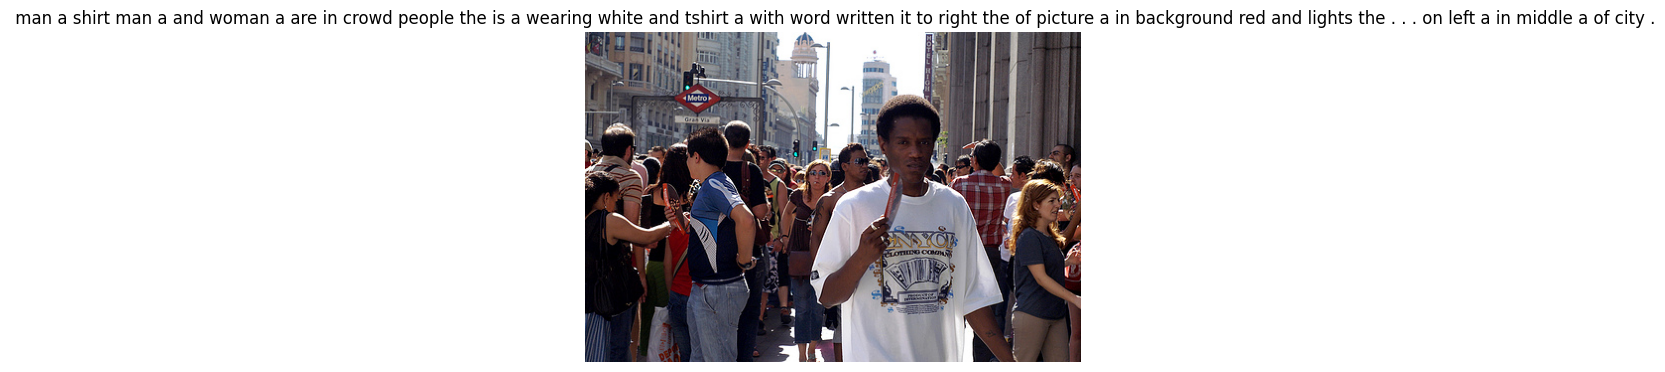

In [57]:
import matplotlib.pyplot as plt

plt.imshow(image)
plt.axis("off")
plt.title(caption)
plt.show()

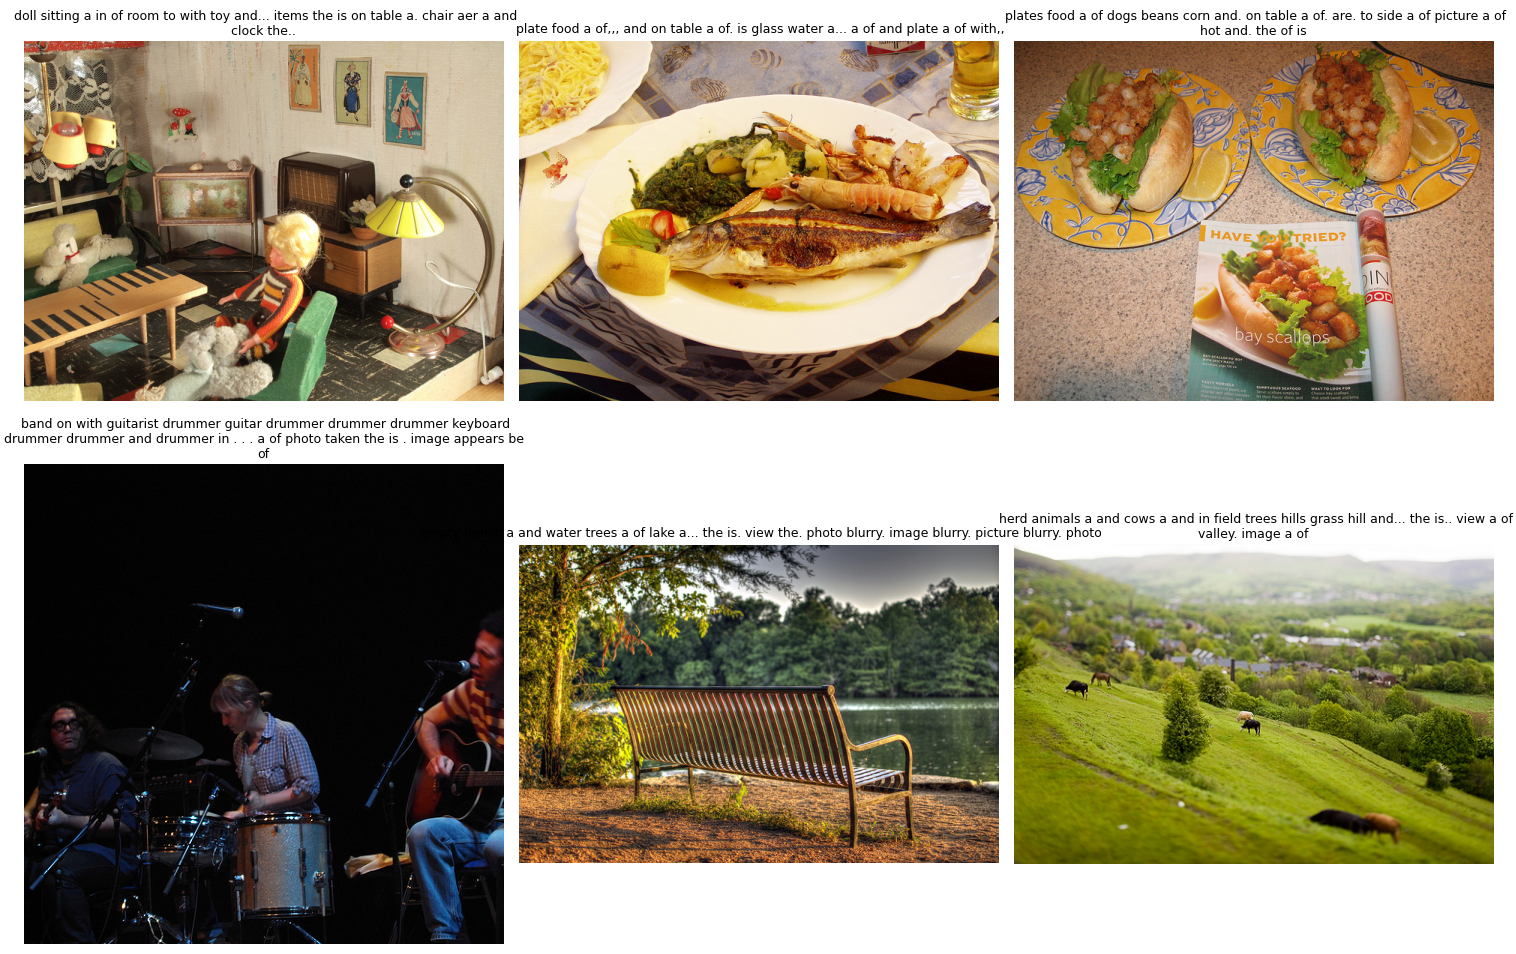

In [58]:
import matplotlib.pyplot as plt
from itertools import islice

num_samples = 6
sample_images = list(islice(test_mapping.items(), num_samples))

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for ax, (image_path, captions) in zip(axes, sample_images):
    image = Image.open(image_path).convert("RGB")
    predicted_caption = generate_caption(image)
    ax.imshow(image)
    ax.axis("off")
    ax.set_title(predicted_caption, fontsize=9, wrap=True)

plt.tight_layout()
plt.show()


In [59]:
from transformers import pipeline

grammar_corrector = pipeline(
    "text2text-generation",
    model="vennify/t5-base-grammar-correction",
    device=0 if torch.cuda.is_available() else -1
)

def correct_grammar(text):
    result = grammar_corrector(f"grammar: {text}", max_length=64)
    return result[0]["generated_text"]

def generate_caption(image):

    pixel_values = processor(
        image,
        return_tensors="pt"
    ).pixel_values.to(device)

    output_ids = model.generate(
        pixel_values=pixel_values,
        max_length=50
    )

    caption = tokenizer.decode(
        output_ids[0],
        skip_special_tokens=True
    )

    return correct_grammar(caption)

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/892M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/892M [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

Device set to use cuda:0


In [60]:
image_path = "/kaggle/input/datasets/eeshawn/flickr30k/flickr30k_images/1005216151.jpg"
image = Image.open(image_path).convert("RGB")

final_caption = generate_caption(image)   # ده هيستخدم النسخة الأخيرة اللي فيها تصحيح الجرامر
print(final_caption)

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=64) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


. . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . 
